In [1]:
import math
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Predicting x1 * x2
def tanh(x):
    return (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))

def tanh_der(x):
    return 1 - tanh(x)**2

def loss(y, ypred):
    return 0.5 * (y - ypred)**2


# Data
data_x = [[i/10, j/10] for i in range(-10, 11) for j in range(-10, 11)]
data_y = [(x1 * x2) for x1, x2 in data_x]

data = list(zip(data_x, data_y))
random.seed(3141592)
random.shuffle(data)

split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

train_x = [x for x, y in train_data]
train_y = [y for x, y in train_data]
test_x = [x for x, y in test_data]
test_y = [y for x, y in test_data]

In [3]:
class MLP:
    def __init__(self, layers):
        self.ws = []
        self.bs = []

        random.seed(3141592)
        for i in range(len(layers) - 1):
            layer_in = layers[i]
            layer_out = layers[i + 1]
            layer_w = [[random.uniform(-1, 1) for _ in range(layer_in)]
                       for _ in range(layer_out)]
            layer_b = [random.uniform(-1, 1) for _ in range(layer_out)]

            self.ws.append(layer_w)
            self.bs.append(layer_b)
            
    def forward(self, x):
        self.act = [x]
        self.zs = []
        
        # Layers
        for i in range(len(self.ws)):
            prev = self.act[-1]
            pre_layer = []
            act_layer = []

            # Neurons
            for j in range(len(self.ws[i])):
                pre = self.bs[i][j]
                for k in range(len(self.ws[i][j])):
                    pre += self.ws[i][j][k] * prev[k]
                
                pre_layer.append(pre)

                if i != len(self.ws) - 1:
                    act_layer.append(tanh(pre))
                else:
                    act_layer.append(pre)
                    
            self.zs.append(pre_layer)
            self.act.append(act_layer)
            
        return self.act[-1][0]

    def backprop(self, y):
        self.grad_w = [[[0.0 for _ in range(len(self.ws[i][j]))]
                        for j in range(len(self.ws[i]))]
                       for i in range(len(self.ws))]
        self.grad_b = [[0.0 for _ in range(len(self.bs[i]))]
                       for i in range(len(self.bs))]
        ypred = self.act[-1][0]
        delta = [0] * len(self.ws)
        delta[-1] = [ypred - y]

        # range(start, stop, step)
        for k in range(len(self.ws) - 2, -1, -1):
            delta[k] = []
            for i in range(len(self.ws[k])):
                dlda = 0.0
                for j in range(len(self.ws[k + 1])):
                    dlda += self.ws[k + 1][j][i] * delta[k + 1][j]
                delta[k].append(dlda * tanh_der(self.zs[k][i]))

        for i in range(len(self.ws)):
            prev = self.act[i]
            for j in range(len(self.ws[i])):
                self.grad_b[i][j] = delta[i][j]
                for k in range(len(prev)):
                    self.grad_w[i][j][k] = delta[i][j] * prev[k]

    def update(self, lr):
        for i in range(len(self.ws)):
            for j in range(len(self.ws[i])):
                for k in range(len(self.ws[i][j])):
                    self.ws[i][j][k] -= lr * self.grad_w[i][j][k]
                self.bs[i][j] -= lr * self.grad_b[i][j]

    def train(self, train_x, train_y, epochs, lr):
        losses = []
        for epoch in range(epochs):
            total_loss = 0

            for x, y in zip(train_x, train_y):
                ypred = self.forward(x)
                total_loss += loss(y, ypred)
                self.backprop(y)
                self.update(lr)

            average_loss = total_loss / len(train_x)
            losses.append(average_loss)
            
            if (epoch + 1) % 100 == 0:
                print(f"Epoch: {epoch+1}/{epochs}, Loss: {average_loss}")
                
        return losses


    def show_params(self):
        for i, (w, b) in enumerate(zip(self.ws, self.bs)):
            layer = "OUTPUT" if i == len(self.ws) - 1 else f"LAYER {i+1}"
            print(layer)
            for j, neuron_w in enumerate(w):
                weights_str = ", ".join(f"{x:.4f}" for x in neuron_w)
                print(f"  Neuron {j+1}:")
                print(f"    Weights: [{weights_str}]")
                print(f"    Bias = {b[j]:.4f}")
            print()

mlp = MLP([2, 8, 8, 1])

Epoch: 100/2000, Loss: 0.0006795237745380497
Epoch: 200/2000, Loss: 0.0002780199905385479
Epoch: 300/2000, Loss: 0.00015780133554953304
Epoch: 400/2000, Loss: 9.996884725589866e-05
Epoch: 500/2000, Loss: 6.544552166502369e-05
Epoch: 600/2000, Loss: 4.373246439583505e-05
Epoch: 700/2000, Loss: 3.032175895325618e-05
Epoch: 800/2000, Loss: 2.2295750007135315e-05
Epoch: 900/2000, Loss: 1.7559747007674843e-05
Epoch: 1000/2000, Loss: 1.4723606896641237e-05
Epoch: 1100/2000, Loss: 1.2951440585334302e-05
Epoch: 1200/2000, Loss: 1.1773900112740833e-05
Epoch: 1300/2000, Loss: 1.0936643742787753e-05
Epoch: 1400/2000, Loss: 1.0302935457567813e-05
Epoch: 1500/2000, Loss: 9.79811628836463e-06
Epoch: 1600/2000, Loss: 9.379957580934361e-06
Epoch: 1700/2000, Loss: 9.023360655331247e-06
Epoch: 1800/2000, Loss: 8.712547584218995e-06
Epoch: 1900/2000, Loss: 8.437042172730164e-06
Epoch: 2000/2000, Loss: 8.189547717119376e-06

[1.0, -1.0] -1.0
     ypred: -0.9914314084230468
[0.8, -1.0] -0.8
     ypred: -0.

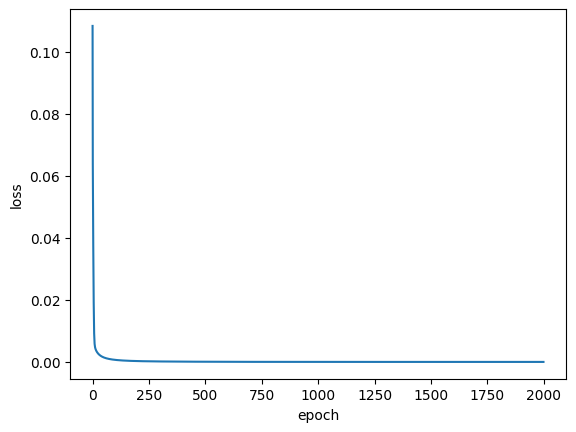

In [4]:
losses = mlp.train(train_x, train_y, epochs=2000, lr=0.01)
print()

for x, y in zip(train_x[:10], train_y[:10]):
    print(x, y)
    print(f"     ypred: {mlp.forward(x)}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

#mlp.show_params()

In [5]:
test_loss = 0
for x, y in zip(test_x, test_y):
    ypred = mlp.forward(x)
    test_loss += loss(y, ypred)

for x, y in zip(test_x[:10], test_y[:10]):
    ypred = mlp.forward(x)
    print(x, y)
    print(f"    ypred: {ypred}")

print("Test Loss:", test_loss / len(test_x))

[-0.9, -0.3] 0.27
    ypred: 0.27224246623233583
[0.9, 1.0] 0.9
    ypred: 0.889162612694173
[0.1, 0.5] 0.05
    ypred: 0.050824340568330406
[1.0, 1.0] 1.0
    ypred: 0.9737260427905209
[0.6, -0.8] -0.48
    ypred: -0.4811987339447982
[0.6, -0.3] -0.18
    ypred: -0.17587974783858806
[0.6, 0.4] 0.24
    ypred: 0.23577905969192914
[0.5, -0.8] -0.4
    ypred: -0.4007379739663608
[0.5, 0.2] 0.1
    ypred: 0.0970149401772119
[0.9, -0.2] -0.18000000000000002
    ypred: -0.18071247280108016
Test Loss: 1.1432408362631248e-05
